In [1]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy.ndimage import gaussian_filter1d

from scipy import stats
import statsmodels.formula.api as smf
from scipy import signal

sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

import matplotlib.animation as ani #this was a good idea that is at the bottom of the "Reward_LFP.ipynb"

%matplotlib inline
%load_ext autoreload
%autoreload 2



In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

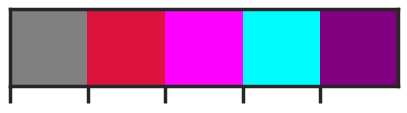

In [3]:
pal=sns.blend_palette(['gray','crimson','magenta','cyan','purple'],5)
sns.palplot(pal)
sns.set_palette(pal)

# Define some functions and variables

In [4]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 210.0 90.0 150.0


In [5]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

---

# First, load in the .npy array and CC_ls
These were creaded and saved using the "1_saving_LFP_arrays" jupyter notebook

In [6]:
allrecs_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\novel_all_rew.npy")

pkl_file = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\novel_cc_ls"

open_file = open(pkl_file, "rb")
CC_ls = pickle.load(open_file)
open_file.close()

CC_ls

['CC067431',
 'CC067432',
 'CC067489',
 'CC067489',
 'CC082255',
 'CC082257',
 'CC082257',
 'CC082257',
 'CC082260',
 'CC082260',
 'CC082260',
 'CC082263',
 'CC082263',
 'CC082263',
 'CC084621',
 'CC084621']

In [7]:
allrecs_arr.shape

(16, 384, 7350)

# Plotting the average of all mice

### Find the strongest VEP ch for each mouse then average

In [8]:
def average_data(group_arr):
    chs_ls = []
    for ii in range(group_arr.shape[0]):
        V1_region = group_arr[ii][200:300,:]
        min_ch = np.where(V1_region == np.amin(V1_region))
        min_ch2 = min_ch[0][0] + 199
        chs_ls.append(group_arr[ii][min_ch2,:])
        
    avg_plot = np.array(chs_ls)
    avg_plot_mean = np.mean(avg_plot, axis=0)
    avg2_plot_mean = np.reshape(avg_plot_mean,(1,len(avg_plot_mean)))
    
    return avg_plot, avg_plot_mean, avg2_plot_mean

In [9]:
avg_groupA = []
avg_groupB = []
for i in range(allrecs_arr.shape[0]):
    if (CC_ls[i] == "CC082263") | (CC_ls[i] == "CC067489") | (CC_ls[i] == "CC082260") | (CC_ls[i] == "CC084621"):
#     if (CC_ls[i] == "CC082260") | (CC_ls[i] == "CC084621"):
        avg_groupA.append(allrecs_arr[i])
    elif (CC_ls[i] == "CC082257") | (CC_ls[i] == "CC067431") | (CC_ls[i] == "CC067432") | (CC_ls[i] == "CC082255"):
#     elif (CC_ls[i] == "CC067432") | (CC_ls[i] == "CC082255"):
        avg_groupB.append(allrecs_arr[i])

avg_groupA_arr = np.array(avg_groupA)
avg_groupB_arr = np.array(avg_groupB)

print(avg_groupA_arr.shape)
print(avg_groupB_arr.shape)

(10, 384, 7350)
(6, 384, 7350)


In [10]:
all_A, mean_A, rs_mean_A = average_data(avg_groupA_arr)
all_B, mean_B, rs_mean_B = average_data(avg_groupB_arr)

print(mean_A.shape)
print(rs_mean_A.shape)

(7350,)
(1, 7350)


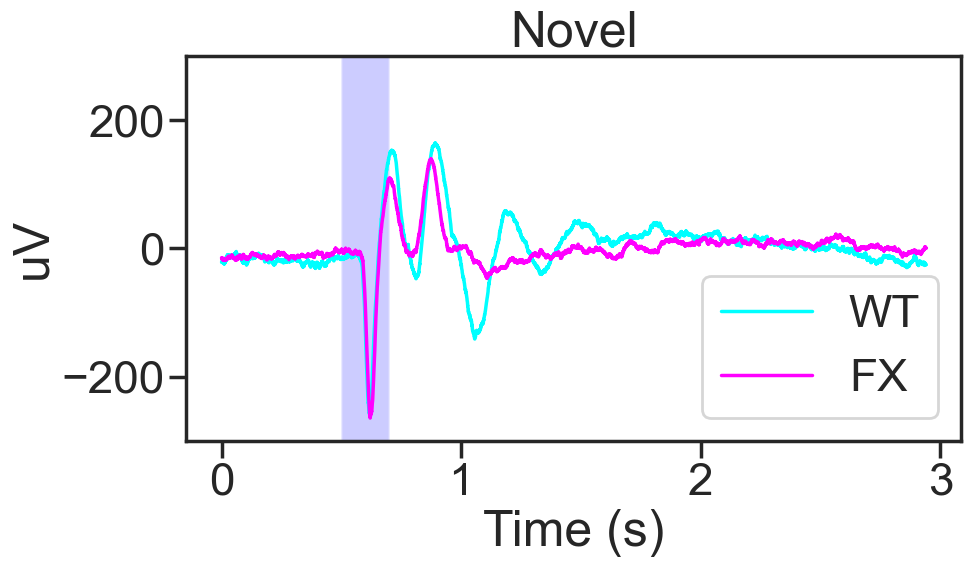

In [11]:
plt.figure(figsize=(10, 5))

time_arr2_A = np.linspace(0, mean_A.shape[0]/sr, mean_A.shape[0])
time_arr2_B = np.linspace(0, mean_A.shape[0]/sr, mean_A.shape[0])

plt.plot(time_arr2_A, mean_A, label='WT', color='cyan')
plt.plot(time_arr2_B, mean_B, label='FX', color='magenta')
plt.legend(loc="lower right")

plt.title('Novel')
plt.xlabel('Time (s)')
plt.ylabel('uV')
plt.ylim([-300,300])
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='b')

# VEP quantification plots

In [12]:
time_windows=[[0.55,0.7],   # VEP 1 time frame
              [0.71,0.85],  # VEP 2 time frame
              [0.86,1],     # VEP 3 time frame
              [1.05,1.15],  # VEP 4 time frame
              [1.2,1.3]]    # VEP 5 time frame


time_windows=[[i[0]*sr,i[1]*sr] for i in time_windows]
depth_bounds=[[200,300],[0,200]] #V1 bounds and hippocampus/Thalamus bounds


V1vep1=allrecs_arr[:,depth_bounds[0][0]:depth_bounds[0][1]
               ,int(time_windows[0][0]):int(time_windows[0][1])
              ].min(axis=-1).min(axis=1)
V1vep2=allrecs_arr[:,depth_bounds[0][0]:depth_bounds[0][1]
               ,int(time_windows[1][0]):int(time_windows[1][1])
              ].min(axis=-1).min(axis=1)
V1vep3=allrecs_arr[:,depth_bounds[0][0]:depth_bounds[0][1]
               ,int(time_windows[2][0]):int(time_windows[2][1])
              ].min(axis=-1).min(axis=1)
V1vep4=allrecs_arr[:,depth_bounds[0][0]:depth_bounds[0][1]
               ,int(time_windows[3][0]):int(time_windows[3][1])
              ].min(axis=-1).min(axis=1)
V1vep5=allrecs_arr[:,depth_bounds[0][0]:depth_bounds[0][1]
               ,int(time_windows[4][0]):int(time_windows[4][1])
              ].min(axis=-1).min(axis=1)
# V1vep6=allrecs_arr[:,depth_bounds[0][0]:depth_bounds[0][1]
#                ,int(time_windows[5][0]):int(time_windows[5][1])
#               ].min(axis=-1).min(axis=1)


In [13]:
V1vep1df=pd.DataFrame({'rec_ind':np.arange(V1vep1.shape[0])
             ,'vepamp':V1vep1
              ,'vep':1
             })
V1vep2df=pd.DataFrame({'rec_ind':np.arange(V1vep2.shape[0])
             ,'vepamp':V1vep2
              ,'vep':2
             })
V1vep3df=pd.DataFrame({'rec_ind':np.arange(V1vep3.shape[0])
             ,'vepamp':V1vep3
              ,'vep':3
             })
V1vep4df=pd.DataFrame({'rec_ind':np.arange(V1vep4.shape[0])
             ,'vepamp':V1vep4
              ,'vep':4
             })
V1vep5df=pd.DataFrame({'rec_ind':np.arange(V1vep5.shape[0])
             ,'vepamp':V1vep5
              ,'vep':5
             })
# V1vep6df=pd.DataFrame({'rec_ind':np.arange(V1vep6.shape[0])
#              ,'vepamp':V1vep6
#               ,'vep':6
#              })

V1vepdf=pd.concat([V1vep1df, V1vep2df, V1vep3df, V1vep4df, V1vep5df]) #V1vep6df

print('Number of vep peaks: {0}'.format(V1vepdf.vep.nunique()))
print('Number of mice: {0}'.format(V1vepdf.rec_ind.nunique()))

V1vepdf.head()

Number of vep peaks: 5
Number of mice: 16


,rec_ind,vepamp,vep
0,0,-330.022749,1
1,1,-251.470474,1
2,2,-303.723330,1
3,3,-340.106900,1
4,4,-310.182764,1


In [14]:
CC_dfls = []
groupls = []
setls = []

for val in V1vepdf.rec_ind:
    CC_dfls.append(CC_ls[val])
    if (CC_ls[val] == "CC082263") | (CC_ls[val] == "CC067489"):
        groupls.append("A")
        setls.append("1")
    elif (CC_ls[val] == "CC082260") | (CC_ls[val] == "CC084621"):
        groupls.append("A")
        setls.append("2")
    elif (CC_ls[val] == "CC082257") | (CC_ls[val] == "CC067431"):
        groupls.append("B")
        setls.append("1")
    elif (CC_ls[val] == "CC067432") | (CC_ls[val] == "CC082255"):
        groupls.append("B")
        setls.append("2")
        
V1vepdf["CC"] = CC_dfls
V1vepdf["group"] = groupls
V1vepdf["set"] = setls

V1vepdf.head()

,rec_ind,vepamp,vep,CC,group,set
0,0,-330.022749,1,CC067431,B,1
1,1,-251.470474,1,CC067432,B,2
2,2,-303.723330,1,CC067489,A,1
3,3,-340.106900,1,CC067489,A,1
4,4,-310.182764,1,CC082255,B,2


In [15]:
V1vepdf.vep.unique()

array([1, 2, 3, 4, 5], dtype=int64)

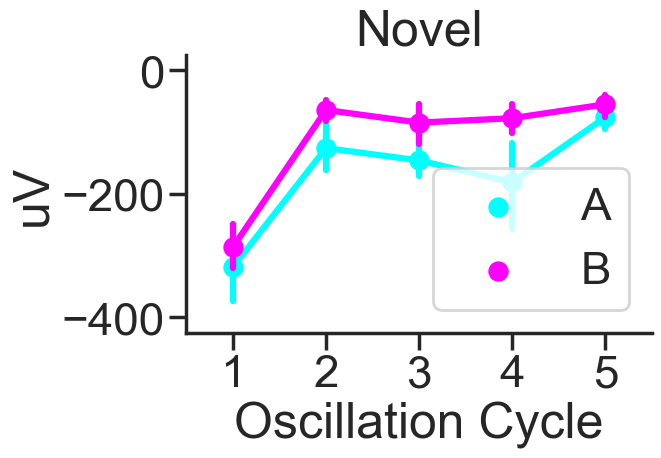

In [16]:
####get averaged traces

# plot_df = V1vepdf[V1vepdf['set']=='2']
plot_df = V1vepdf

p = sns.catplot(data=plot_df,
                x='vep',y='vepamp',
                kind='point',
                legend=False,
                hue='group',
                hue_order=['A','B'],
                height = 5,
                aspect=1.5,
                palette=sns.color_palette(['cyan', 'magenta'])
               )

plt.legend(loc="lower right")
plt.ylabel('uV')
plt.xlabel('Oscillation Cycle')
plt.title('Novel')
plt.ylim([-425,25])

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\novel_VEP_peaks.pdf", transparent=True)

plt.show()

---

# Add in the stats about the above plot here!

### Test if the genotypes are statistically different
k is the number of observations in a,

n is the total number of observations in a and b

In [17]:
varA = plot_df[plot_df['group']=='A'].vepamp.values # aka "a"
varB = plot_df[plot_df['group']=='B'].vepamp.values # aka "b"

stats.ttest_ind(varA, varB)

print('F-value degrees of freedom F x,y')
print('x = {}'.format(5-1)) # 5 cycles
print('y = {}'.format(varA.shape[0]+(varA.shape[0]+varB.shape[0])-2))

stats.f_oneway(varA, varB)

F-value degrees of freedom F x,y
x = 4
y = 128


F_onewayResult(statistic=5.312037275628428, pvalue=0.023838916728989298)

### Test if the individual vep peaks are statistically different across genotype

In [18]:
def VEP_peaks_MWUtest(df):
    stats_results = []
    fstats_results = []
    tukeytest_results = []
    for vep in df.vep.unique():
        foo_df = df[df['vep'] == vep]
        var1 = foo_df[foo_df['group'] == 'A'].vepamp.values
        var2 = foo_df[foo_df['group'] == 'B'].vepamp.values
        result = stats.mannwhitneyu(var1, var2)
        stats_results.append(vep)
        stats_results.append(result)
    return stats_results

In [19]:
novel_stats = VEP_peaks_MWUtest(plot_df)

print('novel')
for idx,val in enumerate(novel_stats):
    print(val) #this is testing WT->FX for each cycle

novel
1
MannwhitneyuResult(statistic=24.0, pvalue=0.5502149953470314)
2
MannwhitneyuResult(statistic=10.0, pvalue=0.03415904394509668)
3
MannwhitneyuResult(statistic=12.0, pvalue=0.057309994745795324)
4
MannwhitneyuResult(statistic=6.0, pvalue=0.010689471247729808)
5
MannwhitneyuResult(statistic=15.0, pvalue=0.11524171990719755)


In [23]:
stats_results = []
fstats_results = []
for vep in plot_df.vep.unique():
    foo_df = plot_df[plot_df['vep'] == vep]
    var1 = foo_df[foo_df['group'] == 'A'].vepamp.values
    var2 = foo_df[foo_df['group'] == 'B'].vepamp.values
    result = stats.ttest_ind(var1, var2)
    fresult = stats.f_oneway(var1, var2)
    
    stats_results.append(vep)
    stats_results.append(result)
    fstats_results.append(vep)
    fstats_results.append(fresult)

stats_results

[1,
 Ttest_indResult(statistic=-0.8125291957999748, pvalue=0.4300888110858251),
 2,
 Ttest_indResult(statistic=-2.146552171117094, pvalue=0.04983594636423773),
 3,
 Ttest_indResult(statistic=-2.639315506012358, pvalue=0.019430144334047512),
 4,
 Ttest_indResult(statistic=-2.073700122116711, pvalue=0.05703703306093282),
 5,
 Ttest_indResult(statistic=-1.2778413866159524, pvalue=0.2220877169953935)]

In [24]:
fstats_results

[1,
 F_onewayResult(statistic=0.6602036940273536, pvalue=0.4300888110858252),
 2,
 F_onewayResult(statistic=4.60768622332751, pvalue=0.04983594636423765),
 3,
 F_onewayResult(statistic=6.965986340277268, pvalue=0.019430144334047526),
 4,
 F_onewayResult(statistic=4.3002321964668635, pvalue=0.05703703306093266),
 5,
 F_onewayResult(statistic=1.6328786093485794, pvalue=0.22208771699539356)]

### Linear Mixed Model analysis
First, for the Amp values x Vep # with a comparison between groups

Second, for the Amp values x group with a comparison between Vep #

In [38]:
plot_df = pd.read_csv(r"U:\Data\Cheng434\Auxilin_KO\mp_csvfiles\mp_20hz_10p.csv")

In [42]:
plot_df.head(5)

,Unnamed: 0,genotype,time,EPSC
0,0,WT,0ms,367.848684
1,1,WT,0ms,272.247306
2,2,WT,0ms,135.152179
3,3,WT,0ms,650.990765
4,4,WT,0ms,107.716877


In [40]:
md = smf.mixedlm("EPSC ~ time", data=plot_df, groups=plot_df["genotype"], re_formula="~time")
mdf = md.fit(method=["lbfgs"])
print(mdf.summary())

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\base\model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 7.669710
  warnings.warn(msg, ConvergenceWarning)


                      Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         EPSC      
No. Observations:           250             Method:                     REML      
No. Groups:                 2               Scale:                      17940.9277
Min. group size:            120             Log-Likelihood:             -1540.9642
Max. group size:            130             Converged:                  No        
Mean group size:            125.0                                                 
----------------------------------------------------------------------------------
                                    Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
----------------------------------------------------------------------------------
Intercept                           307.148   48.718  6.305 0.000  211.662 402.634
time[T.100ms]                        25.545   72.443  0.353 0.724 -116.440 167.530
time[T.150ms]              

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [47]:
mdf.pvalues

Intercept                           2.890061e-10
time[T.100ms]                       7.243686e-01
time[T.150ms]                       8.919445e-01
time[T.200ms]                       9.847799e-01
time[T.250ms]                       9.974989e-01
                                        ...     
time[T.300ms] x time[T.50ms] Cov             NaN
time[T.350ms] x time[T.50ms] Cov             NaN
time[T.400ms] x time[T.50ms] Cov             NaN
time[T.450ms] x time[T.50ms] Cov             NaN
time[T.50ms] Var                             NaN
Length: 65, dtype: float64

In [39]:
plot_df.head(2)

,Unnamed: 0,genotype,time,EPSC
0,0,WT,0ms,367.848684
1,1,WT,0ms,272.247306


In [36]:
plot_df.vep.unique()

array([1, 2, 3, 4, 5], dtype=int64)

In [50]:
md = smf.mixedlm("vepamp ~ vep", data=plot_df, groups=plot_df["group"], re_formula="~vep")
mdf = md.fit(method=["lbfgs"])
print(mdf.summary())

# md = smf.mixedlm("vepamp ~ group", data=plot_df, groups=plot_df["vep"], re_formula="~group")
# mdf = md.fit(method=["lbfgs"])
# print(mdf.summary())

              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    vepamp   
No. Observations:     80         Method:                REML     
No. Groups:           2          Scale:                 7222.7189
Min. group size:      30         Log-Likelihood:        -462.9691
Max. group size:      50         Converged:             Yes      
Mean group size:      40.0                                       
-----------------------------------------------------------------
                 Coef.   Std.Err.   z    P>|z|   [0.025   0.975] 
-----------------------------------------------------------------
Intercept       -273.933  979.099 -0.280 0.780 -2192.931 1645.064
vep               43.918  318.801  0.138 0.890  -580.920  668.756
Group Var       1099.146 4611.117                                
Group x vep Cov   43.117  660.466                                
vep Var            1.691   58.899                                



C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [30]:
mdf.tvalues

Intercept         -0.279781
vep                0.137760
Group Var          0.002805
Group x vep Cov    0.000768
vep Var            0.000338
dtype: float64

In [31]:
mdf.pvalues

Intercept          0.779645
vep                0.890430
Group Var          0.997762
Group x vep Cov    0.999387
vep Var            0.999730
dtype: float64